<a href="https://colab.research.google.com/github/stephenfrein/vucsc8491/blob/main/Week2_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualization

In this notebook, we'll explore principles and techniques for visualizing data in Python.

We'll cover:

* common tools (Matplotlib, Seaborn)
* when to use what kind of visualization
* general principles to follow
* things you should avoid doing
* less common techniques (e.g., 3D, animated, interactive)


## Matplotlib

This is the most common visualization tool in Python. It is a workhorse that other libraries like Seaborn and Pandas use to get graphical work done.

Its name comes from its inspiration - it was created as a tool for doing graphs similar to those in the proprietary MATLAB platform.

General script for using *matplotlib*:

* create a Figure (canvas on which you'll put your visualizations)
* create one or more plots (*"Axes"* in matplotlib-speak)
* plot your data
* add labeling
* show the figure

In [ ]:
# let's graph the passenger classes for the Titanic

import pandas as pd
# get the titanic data so we can graph it
titanic_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
# we did this in Week 1 - uses matplotlib underneath
titanic_df['Pclass'].value_counts().plot(kind='bar')

In [ ]:
class_summary = titanic_df['Pclass'].value_counts()
#display(class_summary)
type(class_summary)

In [ ]:
# let's do a more explicit version for deeper understanding and control

# pyplot is a module within matplotlib
# it allows for an assumed "current" figure to simplify code
# conventional to import it as plt
import matplotlib.pyplot as plt

# get counts by passenger class, sorted by class number
class_summary = titanic_df['Pclass'].value_counts().sort_index()
# this may look like a dataframe
print('class_summary contains:\n')
display(class_summary)
print('-----------')
# but it's really a series with the passenger classes as index values
print('the data type is:\n')
display(type(class_summary))
print('-----------')

# this means create a vertical bar chart using "current" figure
# if no figure is active, a new one gets created
# first arg is list (see square brackets) of x-axis categories
# second arg is y-axis values
plt.bar(["First","Second","Third"], class_summary)
plt.title("Titanic Passengers by Class")
plt.show()

In [ ]:
# this will give you a unique list of unique index values
# for a Series if you don't want to bother coming up with other labels
class_summary.index.astype(str).to_list()


## ??? Reflection ???

What could we do to make the above figure better?

In [ ]:
# label the x and y axis

plt.bar(["First","Second","Third"], class_summary)
plt.xlabel("Passenger Class")         # label x-axis
plt.ylabel("Number of Passengers")    # label y-axis
plt.title("Titanic Passengers by Class")
plt.show()

In [ ]:
# bring grid lines across to make heights more readable

plt.bar(["First","Second","Third"], class_summary)
# extend lines for y axis and make these 60% transparent
plt.grid(axis='y', alpha=0.4)
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Titanic Passengers by Class")
plt.show()

In [ ]:
# change coloring from default

plt.bar(["First","Second","Third"], class_summary,
        # different color for each class and defined edge
        color=["gold","steelblue","dimgray"],  edgecolor="black")
plt.grid(axis='y', alpha=0.4)
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Titanic Passengers by Class")
plt.show()

In [ ]:
# add bar labels

bars = plt.bar(["First","Second","Third"], class_summary,
        color=["gold","steelblue","dimgray"],  edgecolor="black")
# bar labels added with padding to distance from edge of bar
plt.bar_label(bars, padding=4)
plt.grid(axis='y', alpha=0.4)
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Titanic Passengers by Class")
plt.show()

In [ ]:
# increase y-axis range to give that top label more room

bars = plt.bar(["First","Second","Third"], class_summary,
        color=["gold","steelblue","dimgray"],  edgecolor="black")
# bar labels added with padding to distance from edge of bar
plt.bar_label(bars, padding=4)
plt.grid(axis='y', alpha=0.4)
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Titanic Passengers by Class")
# bump up the top of y-axis to 600
plt.ylim(top=600)
plt.show()

The above is just a taste of the kind of control you have - if you can imagine it, you can probably do it in *matplotlib*.

## Exercise 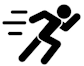

We'll do some visualizations for the Ames Housing data...

In [ ]:
# get the Ames Housing dataset from last week (our modified version)
ah_df = pd.read_csv('https://csc8491.s3.us-east-1.amazonaws.com/Ames_Housing_Modified.csv')

# create a bar plot of the numbers of homes with each Bldg Type
# be sure to label the x and y axis and the bars
# if you need to increase the y axis to give room to the labels, do so

In [ ]:
# get the Ames Housing dataset from last week (our modified version)
ah_df = pd.read_csv('https://csc8491.s3.us-east-1.amazonaws.com/Ames_Housing_Modified.csv')

# create a bar plot of the numbers of homes with each Bldg Type
# be sure to label the x and y axis and the bars
# if you need to increase the y axis to give room to the labels, do so

# <Series Name>.index.to_list() will give you a unique list of unique index values
# for a Series if you don't want to bother coming up with other labels

# ah_df['Bldg Type'].value_counts().plot(kind='bar')


btype_summary = ah_df['Bldg Type'].value_counts().sort_index()


bars = plt.bar(btype_summary.index.to_list(), btype_summary)
# bar labels added with padding to distance from edge of bar
plt.bar_label(bars, padding=4)
plt.xlabel("Building Type")
plt.ylabel("Number of Homes")
plt.title("Homes by Type")
plt.show()

## Choosing a Visualization Type



In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Read real topographical data for Mt. Bruno
url = 'https://raw.githubusercontent.com/plotly/datasets/master/api_docs/mt_bruno_elevation.csv'
z_data = pd.read_csv(url)

# Create an interactive 3D surface plot
fig = go.Figure(data=[go.Surface(z=z_data.values)])

fig.update_layout(
    title='Mt. Bruno Elevation Map',
    autosize=False,
    width=800,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# 1. Load the Data
# In reality, you would load the downloaded CSV file from OpenDataPhilly:
df = pd.read_csv('https://raw.githubusercontent.com/stephenfrein/vucsc8491/refs/heads/main/PhiladelphiaPoliceGeography.csv')

# For demonstration, here is how the data is structured:
data = {
    'census_block': ['Block 1', 'Block 2', 'Block 3', 'Block 4', 'Block 5'],
    'longitude': [-75.1652, -75.1700, -75.1500, -75.1400, -75.1800],
    'latitude': [39.9526, 39.9600, 39.9400, 39.9300, 39.9700],
    'population': [450, 1200, 800, 300, 2000],
    'police_district': ['9th', '9th', '6th', '3rd', '16th']
}
#df = pd.DataFrame(data)

# 2. Generate the 3D Scatter Plot
fig = px.scatter_3d(
    df,
    x='Long',
    y='Lat',
    z='CenPOP2020',
    color='DIST_NUM2025',         # Colors the points by their assigned police district
    # Shows the block name when you hover over a point
    title="3D Population Topology by Philadelphia Police District",
    labels={
        'Long': 'Longitude (E/W)',
        'Lat': 'Latitude (N/S)',
        'CenPOP2020': 'Residential Population',
        'DIST_NUM2025': 'Police District'
    },
    opacity=0.8,
    size='CenPOP2020',               # Makes denser population blocks physically larger in 3D space
    size_max=30
)

# 3. Optimize the Visual Layout
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=50),
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Population Density'
    )
)

# 4. Render the Interactive Graph
fig.show()

In [ ]:
x

In [ ]:
import plotly.express as px
import pandas as pd

df = px.data.gapminder()  # built into plotly!

fig = px.scatter_3d(
    df[df.year == 2007],
    x='gdpPercap', y='lifeExp', z='pop',
    color='continent',
    size='pop',
    size_max=60,
    hover_name='country',
    log_x=True,      # key: log scale on GDP
    log_z=True,
    opacity=0.8,
    title='Gapminder 2007'
)
fig.show()

In [ ]:
fig = px.scatter_3d(
    df,
    x='gdpPercap', y='lifeExp', z='pop',
    animation_frame='year',   # adds the year slider
    color='continent',
    size='pop', size_max=45,
    hover_name='country',
    log_x=True, log_z=True,
    opacity=0.8,
)
fig.show()